In [ ]:
!pip install Biopython

     |████████████████████████████████| 2.3MB 11.1MB/s 


In [ ]:
import tarfile
import pandas as pd
import numpy as np
import re
from datetime import datetime

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv1D, MaxPooling1D

from matplotlib import pyplot as plt

from Bio.Seq import Seq

### Read data

In [ ]:
filename = "training_data.tar.gz"

data = tarfile.open(filename, "r:gz")
data.extractall()
data.close()

In [ ]:
b = open('ghl_gold.fa','r')
bind = b.readlines()
b.close()

u = open('ghl_gold_random.fa','r')
unbind = u.readlines()
u.close()

### Data preprocessing

In [ ]:
bind = [v for v in bind if '>' not in v]
bind = [s.replace('\n', '') for s in bind]
bind = [x.upper() for x in bind]

unbind = [v for v in unbind if '>' not in v]
unbind = [s.replace('\n', '') for s in unbind]
unbind = [x.upper() for x in unbind]

In [ ]:
print(len(bind), len(unbind))

1400090 1400090


##### Reverse complement

In [ ]:
bind_rev = list(range(len(bind)))

for i in range(len(bind)):
  seq = Seq(bind[i])
  rev = seq.reverse_complement()
  bind_rev[i] = str(rev)

unbind_rev = list(range(len(unbind)))

for i in range(len(unbind)):
  seq = Seq(unbind[i])
  rev = seq.reverse_complement()
  unbind_rev[i] = str(rev)

In [ ]:
bind_fb = bind + bind_rev
unbind_fb = unbind + unbind_rev

In [ ]:
bind_label = [1 for i in range(len(bind_fb))]
unbind_label = [0 for i in range(len(unbind_fb))]

In [ ]:
bind_dict = {"seq":bind_fb, "label":bind_label}
unbind_dict = {"seq":unbind_fb, "label":unbind_label}

In [ ]:
bind_df = pd.DataFrame(bind_dict)
unbind_df = pd.DataFrame(unbind_dict)

In [ ]:
df = pd.concat([bind_df, unbind_df])

##### split the dataset

In [ ]:
from sklearn.utils import shuffle

new_df = shuffle(df)
new_df = new_df.reset_index()

In [ ]:
x = new_df.seq
y = new_df.label

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

##### One-hot Encoding

In [ ]:
LE = LabelEncoder()
LE.fit(['A', 'C', 'G', 'T', 'N'])

LabelEncoder()

In [ ]:
start = datetime.now()

for index, row in x_train.items():
  x_train[index] = LE.transform(list(row))

for index, row in x_test.items():
  x_test[index] = LE.transform(list(row))

x_train = to_categorical(x_train.values.tolist())
x_test = to_categorical(x_test.values.tolist())

y_train = to_categorical(y_train.values.tolist())
y_t = to_categorical(y_test.values.tolist())

end = datetime.now()
print("encoding running time : "+str(end-start))

encoding running time : 0:09:11.639130


### CNN model

In [ ]:
model=Sequential()
model.add(Conv1D(filters=64, kernel_size=3, strides=1, padding='valid', input_shape=(20,5), activation='relu'))
model.add(MaxPooling1D(pool_size=3, strides=1, padding='valid'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d (Conv1D)              (None, 18, 64)            1024      
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 16, 64)            0         
_________________________________________________________________
flatten (Flatten)            (None, 1024)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               131200    
_________________________________________________________________
dropout (Dropout)            (None, 128)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 2)                 258       
Total params: 132,482
Trainable params: 132,482
Non-trainable params: 0
__________________________________________________

In [ ]:
history = model.fit(x_train, y_train, epochs=10, validation_split = 0.2)

Epoch 1/10
112008/112008 [==============================] - 458s 4ms/step - loss: 0.3483 - accuracy: 0.8489 - val_loss: 0.3338 - val_accuracy: 0.8555
Epoch 2/10
112008/112008 [==============================] - 456s 4ms/step - loss: 0.3396 - accuracy: 0.8534 - val_loss: 0.3329 - val_accuracy: 0.8563
Epoch 3/10
112008/112008 [==============================] - 454s 4ms/step - loss: 0.3368 - accuracy: 0.8548 - val_loss: 0.3297 - val_accuracy: 0.8585
Epoch 4/10
112008/112008 [==============================] - 453s 4ms/step - loss: 0.3353 - accuracy: 0.8557 - val_loss: 0.3284 - val_accuracy: 0.8593
Epoch 5/10
112008/112008 [==============================] - 451s 4ms/step - loss: 0.3341 - accuracy: 0.8560 - val_loss: 0.3328 - val_accuracy: 0.8558
Epoch 6/10
112008/112008 [==============================] - 450s 4ms/step - loss: 0.3338 - accuracy: 0.8562 - val_loss: 0.3303 - val_accuracy: 0.8584
Epoch 7/10
112008/112008 [==============================] - 447s 4ms/step - loss: 0.3335 - accuracy:

##### Evaluation

Accuracy

In [ ]:
score = model.evaluate(x_test, y_t, verbose=1)
print("score = " + str(round(score[1],2)))

35003/35003 [==============================] - 94s 3ms/step - loss: 0.3269 - accuracy: 0.8592
score = 0.86


loss-epoch curve

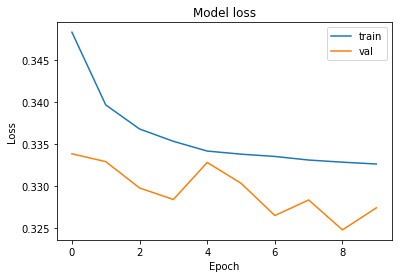

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

precision-recall curve

In [ ]:
probs = model.predict(x_test, verbose=0)[:,1]

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test.values, probs)

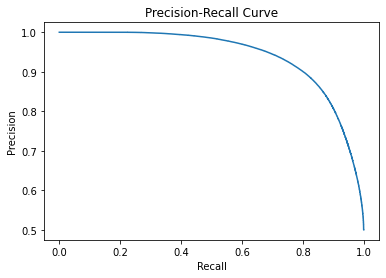

In [ ]:
plt.plot(recall, precision)

plt.title('Precision-Recall Curve')

plt.xlabel('Recall')
plt.ylabel('Precision')

# plt.legend()
plt.show()

ROC curve & AUC

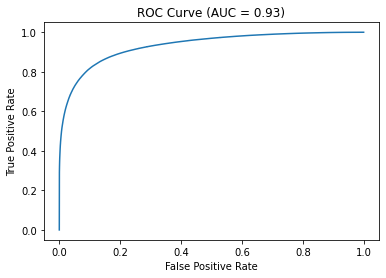

In [ ]:
auc = roc_auc_score(y_test.values, probs)
fpr, tpr, _ = roc_curve(y_test.values, probs)

plt.plot(fpr, tpr)
plt.title('ROC Curve (AUC = ' + str(round(auc,2)) + ')')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()